# PHẦN 2. PHÂN TÍCH PHÂN PHỐI XÁC SUẤT

## Bối cảnh và mục tiêu

Nhu cầu thuê xe theo giờ biến động theo thời điểm trong ngày, loại ngày và điều kiện thời tiết. Phần này tiếp nối kết quả EDA để trả lời câu hỏi: dữ liệu quan sát có hình dạng phân phối nào, và phân phối lý thuyết nào có thể mô tả dữ liệu một cách hợp lý?

Notebook sử dụng dữ liệu đã được xử lý ở Phần 1, nhưng không thay đổi dataset gốc. Các giá trị thời tiết `temp` và `hum` được giữ ở thang chuẩn hóa 0–1. Tổng lượt thuê `cnt` được xem là biến đếm; `casual` và `registered` chỉ được dùng để kiểm tra tính nhất quán, không dùng làm biến giải thích cho mô hình dự báo.

## Câu hỏi nghiên cứu

1. `cnt` có lệch phải, đuôi dài và over-dispersion hay không?
2. Poisson, Negative Binomial, Normal hay Log-normal mô tả `cnt` tốt hơn theo đồ thị và AIC/BIC?
3. `temp` và `hum` gần với Normal hay Beta hơn trên miền giá trị chuẩn hóa?
4. Phân phối và mức trung tâm của `cnt` có khác nhau giữa ngày làm việc và ngày nghỉ không?

## Quy trình phân tích

| Bước | Nội dung | Mục đích |
| --- | --- | --- |
| 2.1 | Xác nhận dữ liệu và thống kê mô tả | Kiểm tra đầu vào, độ lệch và độ phân tán |
| 2.2 | Phân phối thực nghiệm của `cnt` | Nhận diện đuôi phải, cực trị và tỷ lệ tích lũy |
| 2.3 | Fit các phân phối cho `cnt` | So sánh mô hình cho biến đếm và baseline liên tục |
| 2.4 | Phân phối `temp`, `hum` | Đối chiếu Normal và Beta |
| 2.5 | Phân tích theo `workingday` | Cung cấp ngữ cảnh cho phần kiểm định giả thuyết |
| 2.6 | Kết luận và bàn giao | Ghi rõ quyết định, hạn chế và lưu ý downstream |

Các kiểm định goodness-of-fit chỉ là bằng chứng bổ sung. Với cỡ mẫu lớn và dữ liệu theo giờ có tự tương quan, không kết luận chỉ dựa trên p-value.

## 2.1. Kiểm tra dữ liệu đầu vào

### Mục tiêu

Trước khi phân tích hình dạng phân phối, cần xác nhận dữ liệu đầu vào đúng phiên bản, có cấu trúc phù hợp và thỏa các ràng buộc cơ bản của bộ dữ liệu. Các bước kiểm tra tập trung vào kích thước và biến của dữ liệu, giá trị thiếu, dòng/cặp khóa trùng, tính nhất quán của `cnt`, các giá trị bằng 0 và phạm vi của những biến được mô tả.

Đầu vào phân tích là `EDA/cleaned_data/hour_cleaned.csv`. Mỗi dòng biểu diễn một giờ có ghi nhận trong dữ liệu thuê xe đạp Capital Bikeshare tại Washington, D.C. Không sử dụng `day.csv` thay cho dữ liệu theo giờ và không chỉnh sửa file dữ liệu nguồn trong quá trình phân tích.

### Phương pháp

Đọc CSV vào một dataframe trong bộ nhớ. Trước khi kiểm tra, xác định xem file có cột index kỹ thuật do quá trình xuất dữ liệu tạo ra hay không; chỉ loại cột đó khỏi dataframe phân tích nếu thực sự tồn tại. Không loại cột dữ liệu chỉ vì tên cột có dạng chỉ mục nếu chưa xác minh đó là metadata kỹ thuật.

Chuyển `dteday` sang kiểu ngày giờ nếu cột chưa có kiểu phù hợp. Sau đó thực hiện các kiểm tra sau:

- Ghi nhận số dòng, số biến và danh sách cột sau khi xử lý index kỹ thuật.
- Đếm ô thiếu và dòng trùng hoàn toàn.
- Kiểm tra các cặp khóa (`dteday`, `hr`) có bị trùng hay không.
- Đối chiếu quan hệ `cnt = casual + registered`.
- Đếm số dòng có `cnt = 0`, xác định min/max của `cnt` và đếm số dòng có `hum = 0`.
- Tính thống kê mô tả trực tiếp từ dataframe đang phân tích; không chép cố định số liệu cũ vào notebook thay cho việc tính lại.

`casual` và `registered` chỉ được dùng để kiểm tra tính nhất quán với `cnt`. Không sử dụng hai biến này làm biến giải thích cho `cnt`, vì chúng là thành phần cấu thành tổng lượt thuê và có thể gây rò rỉ thông tin.

In [1]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from scipy.optimize import minimize, minimize_scalar
from scipy.special import gammaln, log_ndtr
from scipy.stats import lognorm, nbinom, norm, poisson



# Tìm dữ liệu từ thư mục hiện tại hoặc một trong các thư mục cha.
relative_data_path = Path("EDA") / "cleaned_data" / "hour_cleaned.csv"
search_locations = [Path.cwd(), *Path.cwd().parents]
data_path = next(
    (
        location / relative_data_path
        for location in search_locations
        if (location / relative_data_path).is_file()
    ),
    None,
)

if data_path is None:
    searched_paths = "\n".join(
        str(location / relative_data_path) for location in search_locations
    )
    raise FileNotFoundError(
        "Không tìm thấy EDA/cleaned_data/hour_cleaned.csv. "
        f"Đã kiểm tra các đường dẫn:\n{searched_paths}"
    )

df_raw = pd.read_csv(data_path)

# Loại cột Unnamed do xuất CSV; chỉ loại cột tên index nếu giá trị là
# dãy đánh số tuần tự, để tránh xóa nhầm một biến dữ liệu thật.
unnamed_columns = [
    column
    for column in df_raw.columns
    if re.fullmatch(r"Unnamed:\s*\d+", str(column))
]

technical_index_columns = []
for column in df_raw.columns:
    if str(column).lower() != "index":
        continue

    index_values = pd.to_numeric(df_raw[column], errors="coerce")
    expected_zero_based = pd.Series(range(len(df_raw)), dtype="int64")
    expected_one_based = pd.Series(range(1, len(df_raw) + 1), dtype="int64")

    if index_values.equals(expected_zero_based) or index_values.equals(
        expected_one_based
    ):
        technical_index_columns.append(column)

columns_to_drop = list(dict.fromkeys(unnamed_columns + technical_index_columns))
df = df_raw.drop(columns=columns_to_drop).copy()

if df.empty:
    raise ValueError(f"Dữ liệu đầu vào rỗng: {data_path}")

schema = pd.DataFrame(
    {
        "STT": range(1, len(df.columns) + 1),
        "Tên biến": df.columns,
        "Kiểu dữ liệu": [str(dtype) for dtype in df.dtypes],
    }
)

schema_styled = (
    schema.style
    .format({"STT": "{:,.0f}"})
    .set_caption("Schema dữ liệu sau khi xử lý index kỹ thuật")
    .set_table_styles(
        [
            {
                "selector": "caption",
                "props": [
                    ("caption-side", "top"),
                    ("font-size", "16px"),
                    ("font-weight", "bold"),
                    ("color", "#17365D"),
                    ("text-align", "left"),
                    ("padding", "8px 0"),
                ],
            },
            {
                "selector": "th",
                "props": [
                    ("background-color", "#17365D"),
                    ("color", "white"),
                    ("text-align", "left"),
                    ("padding", "8px"),
                ],
            },
            {
                "selector": "td",
                "props": [
                    ("padding", "7px 10px"),
                    ("border-bottom", "1px solid #e6eaf0"),
                ],
            },
            {
                "selector": "tbody tr:nth-child(even)",
                "props": [("background-color", "#f5f8fc")],
            },
        ]
    )
)

display(schema_styled)

required_columns = {
    "dteday",
    "hr",
    "cnt",
    "casual",
    "registered",
    "hum",
}
missing_columns = sorted(required_columns.difference(df.columns))
if missing_columns:
    raise ValueError(
        "Dữ liệu thiếu các cột bắt buộc: "
        f"{missing_columns}. Các cột hiện có: {df.columns.tolist()}"
    )

# Chuẩn hóa kiểu dữ liệu cần dùng cho kiểm tra.
df["dteday"] = pd.to_datetime(df["dteday"], errors="raise")
for column in ["hr", "cnt", "casual", "registered", "hum"]:
    df[column] = pd.to_numeric(df[column], errors="raise")

# Tính các kết quả kiểm tra từ dữ liệu vừa đọc, không nhập tay số kết quả.
checks = {
    "Số dòng": int(len(df)),
    "Số biến": int(df.shape[1]),
    "Ô thiếu": int(df.isna().sum().sum()),
    "Dòng trùng hoàn toàn": int(df.duplicated().sum()),
    "Cặp (dteday, hr) trùng": int(df.duplicated(["dteday", "hr"]).sum()),
    "Dòng không thỏa cnt = casual + registered": int(
        df["cnt"].ne(df["casual"] + df["registered"]).sum()
    ),
    "Dòng có cnt = 0": int(df["cnt"].eq(0).sum()),
    "cnt nhỏ nhất": float(df["cnt"].min()),
    "cnt lớn nhất": float(df["cnt"].max()),
    "Dòng có hum = 0": int(df["hum"].eq(0).sum()),
}

# Các mốc này dùng làm sanity check theo hợp đồng dữ liệu trong PLAN.md.
baseline = {
    "Số dòng": 17_379,
    "Số biến": 17,
    "Ô thiếu": 0,
    "Dòng trùng hoàn toàn": 0,
    "Cặp (dteday, hr) trùng": 0,
    "Dòng không thỏa cnt = casual + registered": 0,
    "Dòng có cnt = 0": 0,
    "cnt nhỏ nhất": 1.0,
    "cnt lớn nhất": 977.0,
    "Dòng có hum = 0": 0,
}

results = pd.DataFrame(
    [
        {
            "Nội dung kiểm tra": name,
            "Kết quả tính từ dữ liệu": value,
            "Baseline đối chiếu": baseline[name],
            "Khớp baseline": value == baseline[name],
        }
        for name, value in checks.items()
    ]
)

results_display = results.rename(
    columns={
        "Nội dung kiểm tra": "Nội dung kiểm tra",
        "Kết quả tính từ dữ liệu": "Kết quả tính được",
        "Baseline đối chiếu": "Mốc đối chiếu",
        "Khớp baseline": "Đối chiếu",
    }
).copy()

results_display["Đối chiếu"] = results_display["Đối chiếu"].map(
    {True: "Đạt", False: "Cần kiểm tra"}
)

def style_check_status(statuses):
    styles = []
    for status in statuses:
        if status == "Đạt":
            styles.append(
                "background-color: #e8f5e9; color: #1b5e20; font-weight: bold;"
            )
        else:
            styles.append(
                "background-color: #ffebee; color: #b71c1c; font-weight: bold;"
            )
    return styles


results_styled = (
    results_display.style
    .format(
        {
            "Kết quả tính được": "{:,.0f}",
            "Mốc đối chiếu": "{:,.0f}",
        },
        na_rep="—",
    )
    .set_caption("Bảng 2.1. Kiểm tra cấu trúc và chất lượng dữ liệu")
    .set_table_styles(
        [
            {
                "selector": "caption",
                "props": [
                    ("caption-side", "top"),
                    ("font-size", "16px"),
                    ("font-weight", "bold"),
                    ("color", "#17365D"),
                    ("text-align", "left"),
                    ("padding", "8px 0"),
                ],
            },
            {
                "selector": "th",
                "props": [
                    ("background-color", "#17365D"),
                    ("color", "white"),
                    ("text-align", "left"),
                    ("padding", "8px"),
                ],
            },
            {
                "selector": "td",
                "props": [
                    ("padding", "7px 10px"),
                    ("border-bottom", "1px solid #e6eaf0"),
                ],
            },
            {
                "selector": "tbody tr:nth-child(even)",
                "props": [("background-color", "#f5f8fc")],
            },
        ]
    )
    .set_properties(
        subset=["Kết quả tính được", "Mốc đối chiếu"],
        **{"text-align": "right"},
    )
    .apply(style_check_status, subset=["Đối chiếu"])
)

print(f"File dữ liệu: {data_path}")
print(
    "Cột index kỹ thuật đã loại: "
    + (", ".join(map(str, columns_to_drop)) if columns_to_drop else "không có")
)
display(results_styled)
# Không tiếp tục dùng số baseline cũ nếu dữ liệu hiện tại không khớp.
mismatches = results.loc[~results["Khớp baseline"]]
if not mismatches.empty:
    raise RuntimeError(
        "Một hoặc nhiều kết quả khác baseline. "
        "Hãy kiểm tra phiên bản dữ liệu, đường dẫn và tiền xử lý trước khi "
        "diễn giải hoặc tiếp tục các phần phân tích.\n"
        + mismatches.to_string(index=False)
    )

,STT,Tên biến,Kiểu dữ liệu
0,1,instant,int64
1,2,dteday,str
2,3,season,int64
3,4,yr,int64
4,5,mnth,int64
5,6,hr,int64
6,7,holiday,int64
7,8,weekday,int64
8,9,workingday,int64
9,10,weathersit,int64


File dữ liệu: c:\Linh\Programming\DAV\Final\Data_Analytic_and_Visualization_BikeSharing_W.DC\EDA\cleaned_data\hour_cleaned.csv
Cột index kỹ thuật đã loại: không có


,Nội dung kiểm tra,Kết quả tính được,Mốc đối chiếu,Đối chiếu
0,Số dòng,"17,379","17,379",Đạt
1,Số biến,17,17,Đạt
2,Ô thiếu,0,0,Đạt
3,Dòng trùng hoàn toàn,0,0,Đạt
4,"Cặp (dteday, hr) trùng",0,0,Đạt
5,Dòng không thỏa cnt = casual + registered,0,0,Đạt
6,Dòng có cnt = 0,0,0,Đạt
7,cnt nhỏ nhất,1,1,Đạt
8,cnt lớn nhất,977,977,Đạt
9,Dòng có hum = 0,0,0,Đạt



### Kết quả kiểm tra đầu vào

Các kết quả trong bảng là các mốc đã được ghi nhận trong baseline của EDA và kế hoạch phân tích. Khi chạy lại notebook, cần tính lại từng mục; nếu kết quả thực tế khác, cần dừng việc sử dụng các số baseline để điều tra phiên bản dữ liệu, đường dẫn và bước tiền xử lý trước khi cập nhật phần nhận xét.

### Nhận xét

Theo baseline, dữ liệu sau tiền xử lý có 17,379 dòng và 17 biến, không có ô thiếu, dòng trùng hoàn toàn hoặc cặp khóa (`dteday`, `hr`) trùng. Ràng buộc `cnt = casual + registered` được thỏa mãn trên toàn bộ dữ liệu. Không có dòng `cnt = 0`; `cnt` nằm trong khoảng từ 1 đến 977 lượt thuê mỗi giờ.

Việc không có `hum = 0` phù hợp với thông tin tiền xử lý của EDA: 22 giá trị `hum = 0` ban đầu đã được nội suy từ các giờ lân cận. Dữ liệu cũng không được bổ sung 165 giờ thiếu trong chuỗi thời gian. Vì vậy, các mô tả trong phần này áp dụng cho những giờ có bản ghi, không đại diện cho các giờ không xuất hiện trong file.

## 2.2. Thống kê mô tả các biến phân tích


### Mục tiêu

Thống kê mô tả được dùng để tóm tắt mức trung tâm, độ phân tán, khoảng giá trị và độ lệch của các biến `cnt`, `temp` và `hum`. Với `cnt`, tỷ số variance/mean được tính thêm để mô tả mức phân tán tương đối so với giả định equidispersion của phân phối Poisson. Các thống kê này cung cấp bối cảnh cho những phân tích phân phối ở phần tiếp theo; riêng chúng không phải là kiểm định giả thuyết hay bằng chứng nhân quả.

### Phương pháp

Với mỗi biến, báo cáo số quan sát hợp lệ (`n`), mean, median, độ lệch chuẩn (SD), min, Q1, Q3, max, khoảng tứ phân vị (IQR), skewness và kurtosis. IQR được tính bằng `Q3 − Q1`. Riêng `cnt`, tính thêm `variance/mean`.

Trong lần chạy cuối, cần giữ cách tính nhất quán giữa các biến và ghi rõ quy ước kurtosis được dùng. Bảng dưới đây theo các số đã có trong báo cáo trước; precision được giữ ở mức phù hợp với cách trình bày phần TV2. Một số đại lượng được làm tròn nên khi tính lại có thể xuất hiện sai khác nhỏ ở chữ số cuối.


In [2]:
variables = ["cnt", "temp", "hum"]
missing_columns = [column for column in variables if column not in df.columns]

if missing_columns:
    raise ValueError(
        f"Thiếu biến cần tính thống kê: {missing_columns}"
    )

analysis_data = df[variables].apply(pd.to_numeric, errors="raise")

if analysis_data.isna().any().any():
    missing_counts = analysis_data.isna().sum()
    missing_counts = missing_counts[missing_counts > 0]
    raise ValueError(
        "Có giá trị thiếu trong các biến cần mô tả; "
        "cần kiểm tra dữ liệu trước khi tính bảng:\n"
        f"{missing_counts.to_string()}"
    )

summary_rows = []

for variable in variables:
    values = analysis_data[variable]
    q1 = values.quantile(0.25)
    q3 = values.quantile(0.75)
    mean = values.mean()
    variance = values.var(ddof=1)

    summary_rows.append(
        {
            "Biến": variable,
            "n": values.count(),
            "Trung bình": mean,
            "Trung vị": values.median(),
            "Độ lệch chuẩn (SD)": values.std(ddof=1),
            "Min": values.min(),
            "Q1": q1,
            "Q3": q3,
            "Max": values.max(),
            "IQR": q3 - q1,
            "Skewness": values.skew(),
            "Kurtosis (excess)": values.kurt(),
            "Variance/Mean": (
                variance / mean if variable == "cnt" else float("nan")
            ),
        }
    )

summary = pd.DataFrame(summary_rows).set_index("Biến")

summary_styled = (
    summary.style
    .format(
        {
            "n": "{:,.0f}",
            "Trung bình": "{:,.2f}",
            "Trung vị": "{:,.2f}",
            "Độ lệch chuẩn (SD)": "{:,.2f}",
            "Min": "{:,.2f}",
            "Q1": "{:,.2f}",
            "Q3": "{:,.2f}",
            "Max": "{:,.2f}",
            "IQR": "{:,.2f}",
            "Skewness": "{:,.4f}",
            "Kurtosis (excess)": "{:,.4f}",
            "Variance/Mean": "{:,.4f}",
        },
        na_rep="—",
    )
    .set_caption("Bảng 2.2. Thống kê mô tả các biến phân tích")
    .set_table_styles(
        [
            {
                "selector": "caption",
                "props": [
                    ("caption-side", "top"),
                    ("font-size", "16px"),
                    ("font-weight", "bold"),
                    ("color", "#17365D"),
                    ("text-align", "left"),
                    ("padding", "8px 0"),
                ],
            },
            {
                "selector": "th",
                "props": [
                    ("background-color", "#17365D"),
                    ("color", "white"),
                    ("text-align", "center"),
                    ("padding", "8px"),
                ],
            },
            {
                "selector": "td",
                "props": [
                    ("text-align", "right"),
                    ("padding", "7px 10px"),
                    ("border-bottom", "1px solid #e6eaf0"),
                ],
            },
            {
                "selector": "tbody tr:nth-child(even)",
                "props": [("background-color", "#f5f8fc")],
            },
        ]
    )
    .set_properties(
        subset=pd.IndexSlice[:, ["n"]],
        **{"font-weight": "bold"},
    )
)

display(summary_styled)

,n,Trung bình,Trung vị,Độ lệch chuẩn (SD),Min,Q1,Q3,Max,IQR,Skewness,Kurtosis (excess),Variance/Mean
Biến,,,,,,,,,,,,
cnt,"17,379",189.46,142.00,181.39,1.00,40.00,281.00,977.00,241.00,1.2774,1.4172,173.6563
temp,"17,379",0.50,0.50,0.19,0.02,0.34,0.66,1.00,0.32,-0.0060,-0.9418,—
hum,"17,379",0.63,0.63,0.19,0.08,0.48,0.78,1.00,0.30,-0.0828,-0.9119,—



### Kết quả và nhận xét

Bảng 2.2 tóm tắt 17,379 quan sát hợp lệ cho mỗi biến `cnt`, `temp` và `hum`. Độ lệch chuẩn (SD) và phương sai được tính theo mẫu (`ddof=1`); kurtosis được trình bày dưới dạng excess kurtosis. `cnt` được đo bằng lượt thuê / giờ, trong khi `temp` và `hum` là các giá trị chuẩn hóa trên thang 0-1.

Đối với `cnt`, mean là 189.46 lượt thuê/giờ, cao hơn median là 142.00 lượt thuê/giờ. Q1 bằng 40 và Q3 bằng 281, nên IQR là 241 lượt thuê/giờ: một nửa số quan sát nằm trong khoảng từ 40 đến 281 lượt thuê/giờ. Giá trị nhỏ nhất là 1 và lớn nhất là 977 lượt thuê/giờ. Skewness bằng 1.2774, phù hợp với nhận xét mô tả rằng phân phối biên của `cnt` lệch phải và có một số quan sát cao hơn đáng kể so với vùng trung tâm.

Variance/mean của `cnt` bằng 173.6563, lớn hơn nhiều so với 1 — mức tham chiếu cho equidispersion của Poisson. Điều này mô tả độ phân tán quan sát được lớn so với mean, là lý do để xem xét over-dispersion ở phần fit phân phối. Tuy nhiên, riêng tỷ số này không chứng minh phân phối nào sinh ra dữ liệu, cũng không đủ để chọn mô hình cuối cùng.

`temp` có mean và median xấp xỉ 0.50; skewness là -0.0060. `hum` có mean và median xấp xỉ 0.63; skewness là -0.0828. Hai skewness gần 0 cho thấy độ lệch tổng thể của từng biến nhỏ theo thước đo này. Kết quả đó không đồng nghĩa hai biến tuân theo phân phối Normal: vẫn cần quan sát histogram và các phân tích phân phối tiếp theo để đánh giá hình dạng, đuôi hoặc khả năng có nhiều cụm.

Kurtosis excess trong bảng lần lượt là 1.4172 đối với `cnt`, -0.9418 đối với `temp` và -0.9119 đối với `hum`. Đây là thống kê mô tả về hình dạng tương đối của phân phối; không nên diễn giải riêng chỉ số kurtosis như một phép kiểm định hoặc bằng chứng đủ để kết luận về phân phối.

Nhìn chung, thống kê mô tả cho thấy `cnt` vừa lệch phải vừa có độ phân tán lớn so với mean, còn `temp` và `hum` có skewness gần 0 trên thang chuẩn hóa. Các kết quả này mô tả dữ liệu biên ở cấp toàn bộ mẫu; chưa tách cấu trúc theo giờ, mùa hay loại ngày, và không phải kết luận nhân quả.

## 2.3 Phân phối thực nghiệm của `cnt`



### Mục tiêu 

Phần này mô tả hình dạng phân phối thực nghiệm của `cnt` - tổng lượt thuê xe trong một giờ - tập trung vào vùng dữ liệu tập trung, độ lệch, các phân vị, tỷ lệ tích lũy và những quan sát nằm xa phần trung tâm. Phần này giúp nhận diện đặc điểm dữ liệu trước khi fit các phân phối lý thuyết; không dùng riêng hình này để kết luận `cnt` tuân theo một phân phối cụ thể.

### Phương pháp

Phân phối được quan sát qua ba panel trong Hình 2.1:

1. **Histogram kết hợp KDE:** histogram cho thấy mật độ ước lượng theo các khoảng `cnt`; KDE (Kernel Density Estimate - ước lượng mật độ hạt nhân) cung cấp một đường cong làm mượt để tham khảo hình dạng tổng thể. `cnt` là biến đếm nguyên nên KDE được hiểu là xấp xỉ liên tục phục vụ trực quan hóa, không phải PMF (Probability Mass Function - hàm khối xác suất), không thể hiện xác suất quan sát giá trị nguyên cụ thể và không hàm ý rằng lượt thuê có giá trị phân số. Histogram được chuẩn hóa theo mật độ để cùng đơn vị trục tung với KDE. Băng thông làm mượt có thể ảnh hưởng độ cong hoặc các đỉnh nhỏ; vì vậy không diễn giải đường KDE như cấu trúc chính xác của dữ liệu rời rạc.

2. **ECDF (Empirical Cumulative Distribution Function — hàm phân phối tích lũy thực nghiệm):** tại mức `cnt = x`, ECDF cho biết tỷ lệ quan sát có giá trị không vượt quá `x`. Biểu đồ dùng các mức 0%, 25%, 50%, 75% và 100%, đồng thời đánh dấu các phân vị được tính từ dữ liệu đang chạy. Vì `cnt` rời rạc và có các giá trị lặp, ECDF là đường bậc thang; tại một phân vị, giá trị tích lũy thực tế có thể nhảy vượt qua mức phần trăm danh nghĩa.

3. **Boxplot:** tóm tắt median, Q1, Q3, IQR và các điểm vượt khỏi râu hộp theo quy tắc 1.5 × IQR. Điểm nằm ngoài râu là cảnh báo về vị trí tương đối so với phần trung tâm, không tự động đồng nghĩa với lỗi dữ liệu.

Histogram, ECDF và boxplot đều được vẽ trên thang `cnt` gốc để giữ cách diễn giải trực tiếp theo lượt thuê / giờ. Không xóa hoặc biến đổi các giá trị cực trị trong phần mô tả này.


,Số quan sát (n),Mean,Median (P50),Q1 (P25),Q3 (P75),IQR,Min,Max,cnt ≤ 5 (%),cnt > Q3 + 1.5 × IQR (%),Số điểm ngoài hai ngưỡng boxplot
0,"17,379",189.46,142.00,40.00,281.00,241.00,1,977,6.22,2.91,505


C:\Users\ASUS\AppData\Local\Temp\ipykernel_2380\1398757519.py:300: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax_box.boxplot(


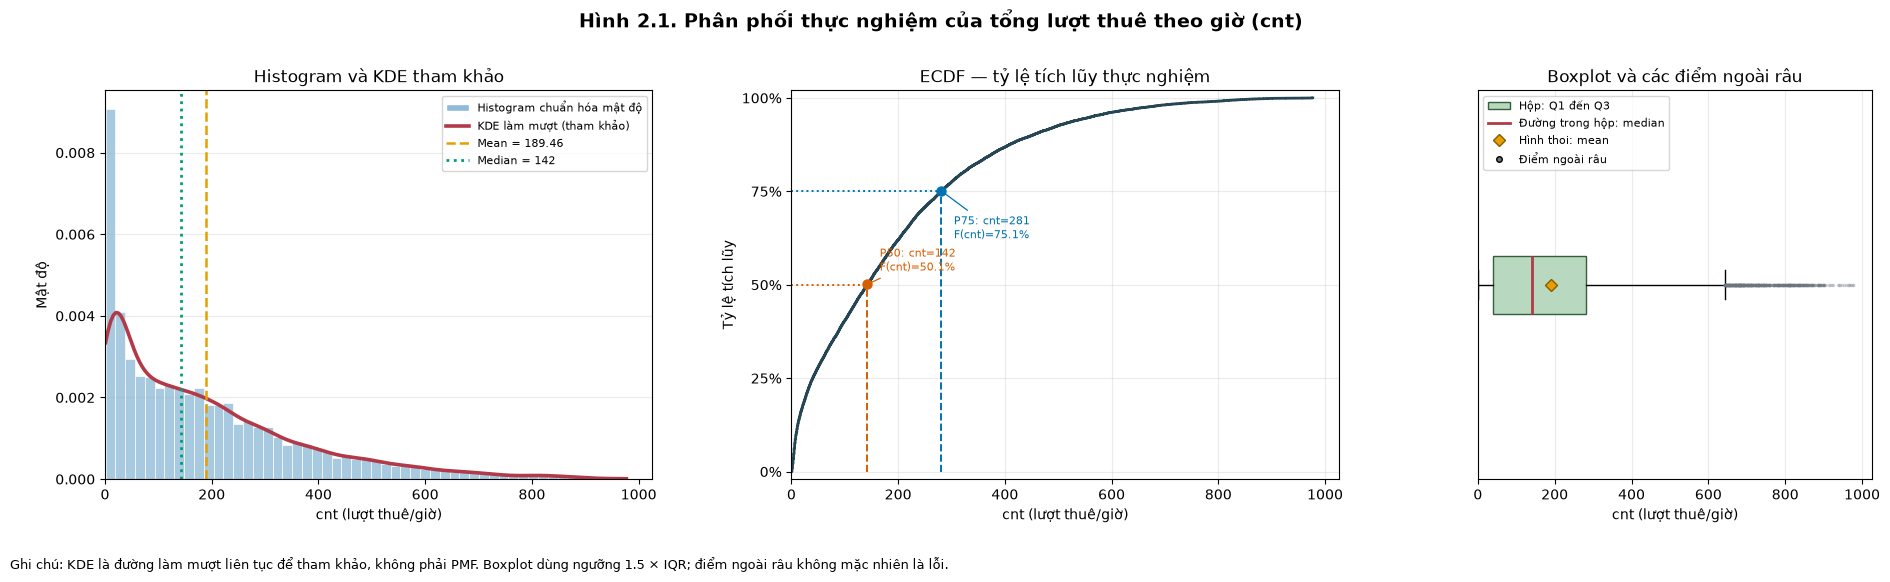

Đã lưu Hình 2.1 tại: c:\Linh\Programming\DAV\Final\Data_Analytic_and_Visualization_BikeSharing_W.DC\Distribution\assets\fig_2_1_cnt_empirical.png
Ngưỡng dưới boxplot Q1 - 1.5 × IQR: -321.50
Ngưỡng trên boxplot Q3 + 1.5 × IQR: 642.50


In [3]:
# Kiểm tra đầu vào của phần vẽ.
if "cnt" not in df.columns:
    raise ValueError("Không tìm thấy cột 'cnt' trong dataframe df.")

cnt_series = pd.to_numeric(df["cnt"], errors="raise")

if cnt_series.isna().any():
    raise ValueError("Cột 'cnt' có giá trị thiếu; cần xử lý/điều tra trước khi vẽ.")

cnt_values = cnt_series.to_numpy(dtype=float)

if not np.isfinite(cnt_values).all():
    raise ValueError("Cột 'cnt' có giá trị không hữu hạn.")

if not np.equal(cnt_values, np.floor(cnt_values)).all():
    raise ValueError("Cột 'cnt' có giá trị không nguyên, không phù hợp với biến đếm.")

if (cnt_values < 0).any():
    raise ValueError("Cột 'cnt' có giá trị âm.")

cnt_values = cnt_values.astype(np.int64)
n = len(cnt_values)

if n == 0:
    raise ValueError("Không có quan sát hợp lệ trong cột 'cnt'.")

# Phân vị tuyến tính nhất quán với pandas quantile mặc định.
quantiles = cnt_series.quantile(
    [0.25, 0.50, 0.75],
    interpolation="linear",
)
q1 = float(quantiles.loc[0.25])
median = float(quantiles.loc[0.50])
q3 = float(quantiles.loc[0.75])
iqr = q3 - q1
mean = float(cnt_series.mean())

lower_fence = q1 - 1.5 * iqr
upper_fence = q3 + 1.5 * iqr

count_at_most_5 = int(np.count_nonzero(cnt_values <= 5))
count_above_upper_fence = int(np.count_nonzero(cnt_values > upper_fence))
count_outside_fences = int(
    np.count_nonzero((cnt_values < lower_fence) | (cnt_values > upper_fence))
)

# Mốc phân vị và giá trị ECDF thực tế tại mỗi phân vị.
quantile_markers = [
    {
        "label": "P50",
        "probability": 0.50,
        "value": median,
        "color": "#D55E00",
        "text_offset": (9, 10),
    },
    {
        "label": "P75",
        "probability": 0.75,
        "value": q3,
        "color": "#0072B2",
        "text_offset": (9, -34),
    },
]

for marker in quantile_markers:
    marker["ecdf_value"] = float(np.mean(cnt_values <= marker["value"]))

# Tóm tắt các mốc thực nghiệm sẽ được dùng trong hình và nhận xét.
empirical_summary = pd.DataFrame(
    [
        {
            "Số quan sát (n)": n,
            "Mean": mean,
            "Median (P50)": median,
            "Q1 (P25)": q1,
            "Q3 (P75)": q3,
            "IQR": iqr,
            "Min": int(cnt_values.min()),
            "Max": int(cnt_values.max()),
            "cnt ≤ 5 (%)": 100 * count_at_most_5 / n,
            "cnt > Q3 + 1.5 × IQR (%)": 100 * count_above_upper_fence / n,
            "Số điểm ngoài hai ngưỡng boxplot": count_outside_fences,
        }
    ]
)

display(
    empirical_summary.style
    .format(
        {
            "Số quan sát (n)": "{:,.0f}",
            "Mean": "{:,.2f}",
            "Median (P50)": "{:,.2f}",
            "Q1 (P25)": "{:,.2f}",
            "Q3 (P75)": "{:,.2f}",
            "IQR": "{:,.2f}",
            "Min": "{:,.0f}",
            "Max": "{:,.0f}",
            "cnt ≤ 5 (%)": "{:.2f}",
            "cnt > Q3 + 1.5 × IQR (%)": "{:.2f}",
            "Số điểm ngoài hai ngưỡng boxplot": "{:,.0f}",
        }
    )
    .set_caption("Tóm tắt phân phối thực nghiệm của cnt")
    .set_table_styles(
        [
            {
                "selector": "caption",
                "props": [
                    ("caption-side", "top"),
                    ("font-size", "16px"),
                    ("font-weight", "bold"),
                    ("color", "#17365D"),
                    ("text-align", "left"),
                    ("padding", "8px 0"),
                ],
            },
            {
                "selector": "th",
                "props": [
                    ("background-color", "#17365D"),
                    ("color", "white"),
                    ("text-align", "center"),
                    ("padding", "8px"),
                ],
            },
            {
                "selector": "td",
                "props": [
                    ("text-align", "right"),
                    ("padding", "7px 10px"),
                    ("border-bottom", "1px solid #e6eaf0"),
                ],
            },
            {
                "selector": "tbody tr:nth-child(even)",
                "props": [("background-color", "#f5f8fc")],
            },
        ]
    )
)

# FD chọn độ rộng bin từ dữ liệu; histogram và KDE đều ở thang mật độ.
histogram_edges = np.histogram_bin_edges(cnt_values, bins="fd")
if len(histogram_edges) < 2:
    raise ValueError("Không thể xác định các khoảng histogram từ cột 'cnt'.")

fig, axes = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(19, 5.8),
    gridspec_kw={"width_ratios": [1.25, 1.25, 0.9]},
)

ax_hist, ax_ecdf, ax_box = axes

# Panel 1: histogram mật độ và KDE liên tục làm đường tham khảo.
ax_hist.hist(
    cnt_values,
    bins=histogram_edges,
    density=True,
    color="#8FBBD9",
    edgecolor="white",
    linewidth=0.6,
    alpha=0.78,
)

sns.kdeplot(
    x=cnt_values,
    ax=ax_hist,
    color="#B23A48",
    linewidth=2.6,
    bw_adjust=1.0,
    cut=0,
    clip=(0, None),
)

ax_hist.axvline(
    mean,
    color="#E69F00",
    linestyle="--",
    linewidth=1.8,
)
ax_hist.axvline(
    median,
    color="#009E73",
    linestyle=":",
    linewidth=2.0,
)

hist_legend = [
    Patch(
        facecolor="#8FBBD9",
        edgecolor="white",
        label="Histogram chuẩn hóa mật độ",
    ),
    Line2D(
        [0],
        [0],
        color="#B23A48",
        linewidth=2.6,
        label="KDE làm mượt (tham khảo)",
    ),
    Line2D(
        [0],
        [0],
        color="#E69F00",
        linestyle="--",
        linewidth=1.8,
        label=f"Mean = {mean:.2f}",
    ),
    Line2D(
        [0],
        [0],
        color="#009E73",
        linestyle=":",
        linewidth=2.0,
        label=f"Median = {median:.0f}",
    ),
]

ax_hist.legend(handles=hist_legend, fontsize=8, frameon=True)
ax_hist.set_title("Histogram và KDE tham khảo")
ax_hist.set_xlabel("cnt (lượt thuê/giờ)")
ax_hist.set_ylabel("Mật độ")
ax_hist.set_xlim(left=0)
ax_hist.grid(axis="y", alpha=0.25)

# Panel 2: ECDF thực nghiệm, dựng trực tiếp từ tần suất các giá trị nguyên.
unique_values, frequencies = np.unique(cnt_values, return_counts=True)
cumulative_probabilities = np.cumsum(frequencies) / n

ecdf_x = np.concatenate(([unique_values[0] - 1], unique_values))
ecdf_y = np.concatenate(([0.0], cumulative_probabilities))

ax_ecdf.step(
    ecdf_x,
    ecdf_y,
    where="post",
    color="#264653",
    linewidth=2.0,
    label="ECDF thực nghiệm",
)

for marker in quantile_markers:
    probability = marker["probability"]
    value = marker["value"]
    ecdf_value = marker["ecdf_value"]
    color = marker["color"]

    # Đường ngang biểu thị mức phần trăm danh nghĩa; đường đứng đến đúng
    # giá trị ECDF quan sát tại phân vị, có thể cao hơn do các bước nhảy.
    ax_ecdf.hlines(
        probability,
        xmin=0,
        xmax=value,
        color=color,
        linestyle=":",
        linewidth=1.4,
    )
    ax_ecdf.vlines(
        value,
        ymin=0,
        ymax=ecdf_value,
        color=color,
        linestyle="--",
        linewidth=1.4,
    )
    ax_ecdf.scatter(
        [value],
        [ecdf_value],
        color=color,
        s=42,
        zorder=4,
    )
    ax_ecdf.annotate(
        f"{marker['label']}: cnt={value:g}\nF(cnt)={ecdf_value:.1%}",
        xy=(value, ecdf_value),
        xytext=marker["text_offset"],
        textcoords="offset points",
        color=color,
        fontsize=8,
        arrowprops={
            "arrowstyle": "-",
            "color": color,
            "lw": 0.9,
        },
    )

ax_ecdf.set_title("ECDF — tỷ lệ tích lũy thực nghiệm")
ax_ecdf.set_xlabel("cnt (lượt thuê/giờ)")
ax_ecdf.set_ylabel("Tỷ lệ tích lũy")
ax_ecdf.set_yticks([0, 0.25, 0.50, 0.75, 1.00])
ax_ecdf.set_yticklabels(["0%", "25%", "50%", "75%", "100%"])
ax_ecdf.set_ylim(-0.02, 1.02)
ax_ecdf.set_xlim(left=0)
ax_ecdf.grid(alpha=0.25)

# Panel 3: boxplot giữ lại các điểm ngoài râu; không tự xóa quan sát.
ax_box.boxplot(
    cnt_values,
    vert=False,
    whis=1.5,
    showfliers=True,
    showmeans=True,
    patch_artist=True,
    boxprops={
        "facecolor": "#B8D8C0",
        "edgecolor": "#355E3B",
    },
    medianprops={
        "color": "#B23A48",
        "linewidth": 2,
    },
    meanprops={
        "marker": "D",
        "markerfacecolor": "#E69F00",
        "markeredgecolor": "#8A5A00",
        "markersize": 6,
    },
    flierprops={
        "marker": "o",
        "markerfacecolor": "#6C757D",
        "markeredgecolor": "none",
        "markersize": 2.5,
        "alpha": 0.28,
    },
)

ax_box.set_title("Boxplot và các điểm ngoài râu")
ax_box.set_xlabel("cnt (lượt thuê/giờ)")
ax_box.set_yticks([])
ax_box.set_xlim(left=0)
ax_box.grid(axis="x", alpha=0.25)
ax_box.legend(
    handles=[
        Patch(
            facecolor="#B8D8C0",
            edgecolor="#355E3B",
            label="Hộp: Q1 đến Q3",
        ),
        Line2D(
            [0],
            [0],
            color="#B23A48",
            linewidth=2,
            label="Đường trong hộp: median",
        ),
        Line2D(
            [0],
            [0],
            marker="D",
            color="none",
            markerfacecolor="#E69F00",
            markeredgecolor="#8A5A00",
            label="Hình thoi: mean",
        ),
        Line2D(
            [0],
            [0],
            marker="o",
            color="none",
            markerfacecolor="#6C757D",
            markersize=4,
            label="Điểm ngoài râu",
        ),
    ],
    fontsize=8,
    frameon=True,
    loc="upper left",
)

fig.suptitle(
    "Hình 2.1. Phân phối thực nghiệm của tổng lượt thuê theo giờ (cnt)",
    fontsize=14,
    fontweight="bold",
)
fig.text(
    0.01,
    0.015,
    (
        "Ghi chú: KDE là đường làm mượt liên tục để tham khảo, không phải PMF. "
        "Boxplot dùng ngưỡng 1.5 × IQR; điểm ngoài râu không mặc nhiên là lỗi."
    ),
    fontsize=9,
    ha="left",
)

fig.subplots_adjust(
    left=0.06,
    right=0.99,
    top=0.84,
    bottom=0.17,
    wspace=0.28,
)

# Xác định thư mục Distribution từ working directory hoặc thư mục cha.
search_paths = [Path.cwd(), *Path.cwd().parents]
distribution_dir = next(
    (path for path in search_paths if path.name.lower() == "distribution"),
    None,
)

if distribution_dir is None:
    project_root = next(
        (path for path in search_paths if (path / "Distribution").is_dir()),
        None,
    )
    if project_root is None:
        raise FileNotFoundError(
            "Không tìm thấy thư mục Distribution từ working directory hiện tại."
        )
    distribution_dir = project_root / "Distribution"

assets_dir = distribution_dir / "assets"
assets_dir.mkdir(parents=True, exist_ok=True)
figure_path = assets_dir / "fig_2_1_cnt_empirical.png"

fig.savefig(figure_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close(fig)

print(f"Đã lưu Hình 2.1 tại: {figure_path}")
print(f"Ngưỡng dưới boxplot Q1 - 1.5 × IQR: {lower_fence:.2f}")
print(f"Ngưỡng trên boxplot Q3 + 1.5 × IQR: {upper_fence:.2f}")

**Lưu ý khi đọc hình:**

- Histogram dùng `density=True` nên chiều cao biểu diễn mật độ theo khoảng, không phải số quan sát hay xác suất của một giá trị `cnt` nguyên cụ thể.
- KDE cũng biểu diễn mật độ liên tục; đường KDE được vẽ giới hạn ở miền không âm để không hiển thị mật độ âm, những thao tác giới hạn đường vẽ không phải hiệu chỉnh biến và KDE vẫn chỉ là công cụ làm mượt.
- ECDF được tính từ tần suất các giá trị thực, không qua binning hoặc làm mượt. Nhãn F(cnt) trên marker cho biết giá trị tích lũy tại phân vị; vì dữ liệu rời rạc, giá trị này có thể lớn hơn P50 hoặc P75 danh nghĩa.
- Boxplot dùng ngưỡng $Q1 - 1.5\times IQR$ và $Q3 + 1.5\times IQR$ để để xác định điểm ngoài râu. Đây là quy tắc tóm tắt, không phải quy trình phát hiện lỗi dữ liệu.


### Kết quả

cnt có mean 189.46 lượt thuê / giờ, median 142 lượt thuê/giờ, Q1 = 40, Q3 = 281 và IQR = 241 lượt thuê/giờ. Giá trị quan sát nằm trong khoảng từ 1 đến 977. Mean cao hơn median và skewness bằng 1.2774, phù hợp với nhận xét phân phối có đuôi phải.

ECDF giúp đọc trực tiếp các tỷ lệ tích lũy quanh median và Q3. Các mốc này phải được tính lại trong notebook; giá trị baseline median = 142 và Q3 = 281 chỉ dùng để đối chiếu. Do dữ liệu có nhiều giá trị `cnt` nguyên lặp lại, đường ECDF có các bước nhảy, nên không nhất thiết đường ngang P50/P75 sẽ cắt đường ECDF đúng tại điểm giao nhau với median/Q3.

Theo baseline, 6.22% quan sát có cnt ≤ 5; 2.91% có cnt > 642.5(ngoại lai ngưỡng trên), với 642.5 là ngưỡng Q3 + 1.5 × IQR tương ứng các phân vị baseline. Các tỷ lệ này cần được tính lại từ dữ liệu đang phân tích thay vì nhập cố định.

### Nhận xét

Các chỉ báo về mean, median và skewness nhất quán với phân phối `cnt` lệch phải: phần lớn giờ nằm thấp hơn một số giá trị nhu cầu cao, khiến mean lớn hơn median và phân phối kéo dài về phía các giá trị lớn. ECDF bổ sung thông tin về tỷ lệ tích lũy mà histogram không thể hiện trực tiếp; boxplot tóm tắt vùng giữa và làm nổi bật các điểm xa vùng này.

Các quan sát vượt ngưỡng boxplot không được tự động loại bỏ. Baseline EDA đánh giá các đỉnh nhu cầu cao là hợp lệ; vì vậy phần phân tích giữ nguyên các quan sát, không diễn giải điểm nằm ngoài râu hộp là lỗi nếu chưa có bằng chứng độc lập. Tương tự, việc dữ liệu hiện có min `cnt = 1` và không có `cnt = 0` chỉ mô tả file đang phân tích; không đủ để kết luận cơ chế ghi nhận là zero-truncated hoặc để khẳng định điều gì về các giờ không có bản ghi.

KDE được dùng như lớp làm mượt bổ trợ để người đọc quan sát xu hướng hình dạng; nó không thay thế ECDF hoặc phân phối khối thực nghiệm. Các nhận xét về cnt ở đây vẫn là mô tả phân phối biên trên toàn bộ quan sát, chưa tách riêng ảnh hưởng của giờ trong ngày, loại ngày, mùa hay thời tiết.

## 2.4 So sánh mô hình phân phối cho cnt


,Mô hình,Tham số MLE,k,Log-likelihood,AIC,BIC,Trạng thái fit
2,Normal cắt tại 0,mu = -3334.65; sigma = 837.011,2,"-108,500.467","217,004.934","217,020.460",MLE hữu hạn (alpha = 3.9840)
3,Log-normal (loc = 0),shape = 1.48609; scale = 93.3244,2,"-110,377.023","220,758.045","220,773.571",MLE dạng đóng; loc cố định bằng 0


Số quan sát dương dùng để fit: n = 17,379
log(n) = 9.7630
Chỉ so sánh AIC/BIC giữa hai mô hình rời rạc với nhau, và giữa hai baseline liên tục với nhau.
Khối xác suất NB zero-truncated bị lược khỏi hình (k > max(cnt) = 977): 0.01019553


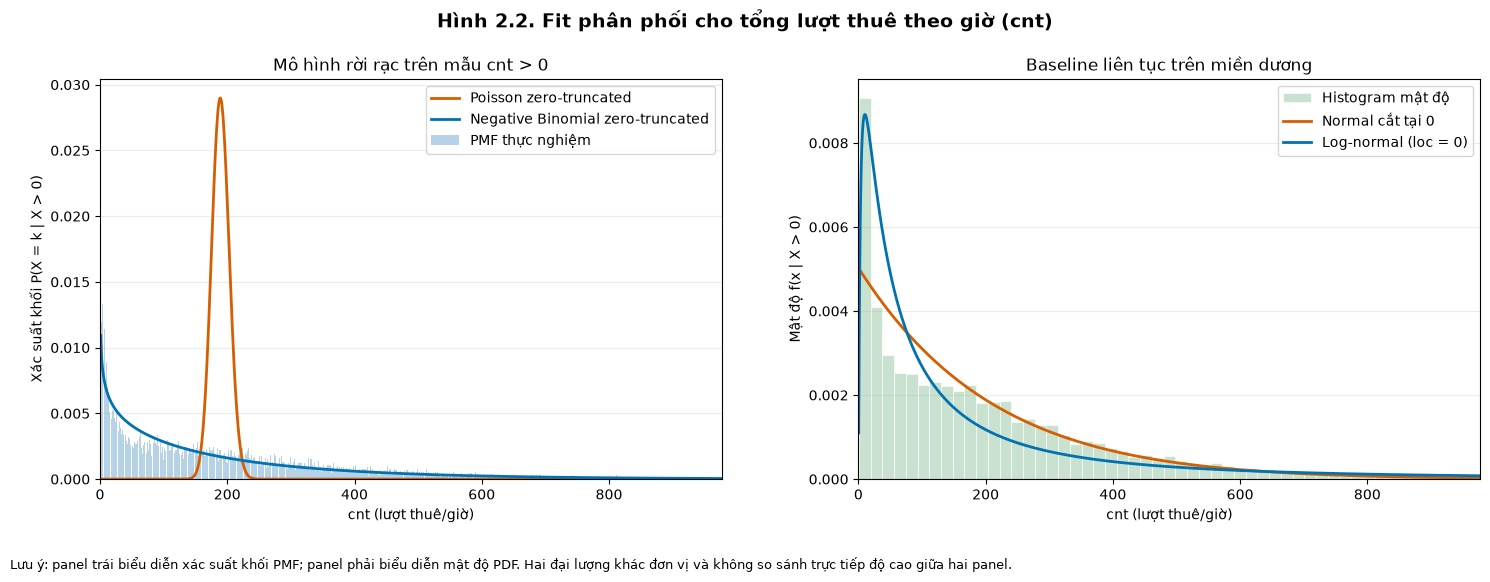

Đã lưu Hình 2.2 tại: c:\Linh\Programming\DAV\Final\Data_Analytic_and_Visualization_BikeSharing_W.DC\Distribution\assets\fig_2_2_cnt_fits.png
Tổng PMF trong miền 1..max(cnt): Poisson=1.000000; Negative Binomial=0.989804; thực nghiệm=1.000000
Khối xác suất NB zero-truncated bị lược khỏi hình (k > max(cnt) = 977): 0.01019553


In [5]:
# ------------------------------------------------------------
# 1. Kiểm tra và chuẩn bị mẫu dương
# ------------------------------------------------------------
if "cnt" not in df.columns:
    raise ValueError("Không tìm thấy cột 'cnt' trong dataframe df.")

cnt_series = pd.to_numeric(df["cnt"], errors="raise")

if cnt_series.isna().any():
    raise ValueError("Cột 'cnt' có giá trị thiếu.")

cnt_values = cnt_series.to_numpy(dtype=float)

if not np.isfinite(cnt_values).all():
    raise ValueError("Cột 'cnt' có giá trị không hữu hạn.")

if not np.equal(cnt_values, np.floor(cnt_values)).all():
    raise ValueError("Cột 'cnt' phải là số nguyên vì đây là biến đếm.")

if (cnt_values < 0).any():
    raise ValueError("Cột 'cnt' có giá trị âm.")

# Theo xác nhận của nhóm, cnt=0 đã bị loại trong bước chuẩn bị dữ liệu.
# Nếu còn giá trị 0, dừng để không âm thầm đổi mẫu.
if (cnt_values == 0).any():
    raise ValueError(
        "Dữ liệu hiện tại còn cnt=0. Không thể dùng trực tiếp cell này như "
        "mẫu zero-truncated cho tới khi xác minh lại quy trình lọc."
    )

if len(cnt_values) == 0:
    raise ValueError("Không có quan sát cnt dương để fit.")

cnt = cnt_values.astype(np.int64)
n = len(cnt)
max_cnt = int(cnt.max())
cnt_mean = float(cnt.mean())
cnt_sd = float(cnt.std(ddof=1))

if cnt_sd <= 0:
    raise ValueError("cnt không có độ biến thiên; không thể fit các mô hình này.")


# ------------------------------------------------------------
# 2. Các hàm likelihood, AIC và BIC
# ------------------------------------------------------------
def calculate_aic(log_likelihood, parameter_count):
    return -2.0 * log_likelihood + 2.0 * parameter_count


def calculate_bic(log_likelihood, parameter_count, sample_size):
    return (
        -2.0 * log_likelihood
        + parameter_count * np.log(sample_size)
    )


# ------------------------------------------------------------
# 3. Poisson zero-truncated: MLE của lambda
#
# log P(X=k | X>0) =
# log P_Poisson(X=k) - log(1 - P_Poisson(X=0))
# ------------------------------------------------------------
def poisson_truncated_negative_log_likelihood(log_lambda):
    lambda_value = float(np.exp(log_lambda))

    if not np.isfinite(lambda_value) or lambda_value <= 0:
        return np.inf

    log_positive_probability = np.log(-np.expm1(-lambda_value))
    log_likelihood = (
        np.sum(cnt * np.log(lambda_value) - lambda_value - gammaln(cnt + 1))
        - n * log_positive_probability
    )

    if not np.isfinite(log_likelihood):
        return np.inf

    return -float(log_likelihood)


poisson_fit = minimize_scalar(
    poisson_truncated_negative_log_likelihood,
    bounds=(np.log(1e-8), np.log(max_cnt * 100.0)),
    method="bounded",
    options={"xatol": 1e-12},
)

if not poisson_fit.success or not np.isfinite(poisson_fit.fun):
    raise RuntimeError(
        "MLE Poisson zero-truncated không hội tụ: "
        f"{poisson_fit.message}"
    )

poisson_lambda = float(np.exp(poisson_fit.x))
poisson_log_likelihood = -float(poisson_fit.fun)

if poisson_lambda <= 0 or not np.isfinite(poisson_lambda):
    raise RuntimeError("Ước lượng lambda của Poisson không hợp lệ.")


# ------------------------------------------------------------
# 4. Negative Binomial zero-truncated: MLE của size và prob
#
# Dùng tham số tối ưu hóa log(size), log(mean_untruncated) để bảo đảm
# hai tham số luôn dương. Chuyển sang prob = size / (size + mean).
# scipy.stats.nbinom dùng đúng tham số hóa này:
# P(X=0) = prob ** size.
# ------------------------------------------------------------
def negative_binomial_log_likelihood(log_parameters):
    log_size, log_mean = log_parameters
    size = float(np.exp(log_size))
    mean_untruncated = float(np.exp(log_mean))

    if (
        not np.isfinite(size)
        or not np.isfinite(mean_untruncated)
        or size <= 0
        or mean_untruncated <= 0
    ):
        return -np.inf

    log_prob = -np.log1p(mean_untruncated / size)
    log_one_minus_prob = -np.log1p(size / mean_untruncated)
    prob = float(np.exp(log_prob))

    # log P_NB(X=0) = size * log(prob).
    log_p_zero = size * log_prob
    log_positive_probability = np.log(-np.expm1(log_p_zero))

    log_pmf = (
        gammaln(cnt + size)
        - gammaln(size)
        - gammaln(cnt + 1)
        + size * log_prob
        + cnt * log_one_minus_prob
    )

    log_likelihood = np.sum(log_pmf) - n * log_positive_probability

    if not np.isfinite(log_likelihood):
        return -np.inf

    return float(log_likelihood)


def negative_binomial_negative_log_likelihood(log_parameters):
    log_likelihood = negative_binomial_log_likelihood(log_parameters)
    return -log_likelihood if np.isfinite(log_likelihood) else np.inf


log_mean_start = np.log(cnt_mean)
nb_bounds = [
    (np.log(1e-5), np.log(1e6)),  # log(size)
    (np.log(1e-5), np.log(max_cnt * 100.0)),  # log(mean)
]

nb_start_sizes = [0.1, 0.5, 1.0, 5.0, 25.0, 100.0]
nb_start_mean_factors = [0.5, 0.8, 1.0, 1.2]

nb_candidates = []

for start_size in nb_start_sizes:
    for mean_factor in nb_start_mean_factors:
        start_mean = max(cnt_mean * mean_factor, 1e-4)
        start = np.log([start_size, start_mean])

        result = minimize(
            negative_binomial_negative_log_likelihood,
            x0=start,
            method="L-BFGS-B",
            bounds=nb_bounds,
            options={"maxiter": 5000, "ftol": 1e-12, "gtol": 1e-8},
        )

        if result.success and np.isfinite(result.fun):
            nb_candidates.append(result)

if not nb_candidates:
    raise RuntimeError(
        "Không có lần tối ưu MLE Negative Binomial zero-truncated nào "
        "hội tụ thành công."
    )

nb_fit = min(nb_candidates, key=lambda result: result.fun)
nb_size, nb_mean_untruncated = np.exp(nb_fit.x)
nb_size = float(nb_size)
nb_mean_untruncated = float(nb_mean_untruncated)
nb_prob = nb_size / (nb_size + nb_mean_untruncated)
nb_log_likelihood = -float(nb_fit.fun)

if (
    nb_size <= 0
    or not 0 < nb_prob < 1
    or not np.isfinite(nb_log_likelihood)
):
    raise RuntimeError(
        "Tham số hoặc log-likelihood của Negative Binomial không hợp lệ."
    )

# ------------------------------------------------------------
# 5. Normal cắt tại 0: profile likelihood
# ------------------------------------------------------------
# alpha = mu / sigma.
# Với mỗi alpha, tối ưu sigma theo profile likelihood.
# Nếu supremum nằm ở alpha -> -infinity thì Normal không có MLE hữu hạn;
# giới hạn tương ứng là Exponential trên miền dương.
# ------------------------------------------------------------
cnt_mean_x = float(np.mean(cnt_values))
cnt_mean_x2 = float(np.mean(cnt_values**2))
def profile_log_likelihood_alpha(alpha):
    if not np.isfinite(alpha):
        return np.inf
    
    sigma = (alpha * cnt_mean_x + np.sqrt(alpha**2 * cnt_mean_x**2 + 4.0 * cnt_mean_x2)) / 2.0
    
    if sigma <= 0:
        return np.inf
    
    # log_ndtr tính log(Phi(x)) cực kỳ ổn định chống underflow
    log_prob_pos = log_ndtr(-alpha)
    
    ll_mean = (
        -np.log(sigma) 
        - cnt_mean_x2 / (2.0 * sigma**2) 
        - (alpha * cnt_mean_x) / sigma 
        - (alpha**2) / 2.0 
        - 0.5 * np.log(2.0 * np.pi) 
        - log_prob_pos
    )
    return -float(ll_mean)
# Tối ưu hóa profile likelihood. 
# Nếu tồn tại MLE hữu hạn, đỉnh alpha hiếm khi vượt quá 20-30 cho dữ liệu thực.
normal_alpha_res = minimize_scalar(
    profile_log_likelihood_alpha,
    bounds=(-10.0, 50.0),
    method='bounded',
    options={'xatol': 1e-12}
)
if normal_alpha_res.success and np.isfinite(normal_alpha_res.fun) and normal_alpha_res.x < 49.9:
    normal_mle_finite = True
    normal_alpha = float(normal_alpha_res.x)
    normal_sigma = float((normal_alpha * cnt_mean_x + np.sqrt(normal_alpha**2 * cnt_mean_x**2 + 4.0 * cnt_mean_x2)) / 2.0)
    normal_mu = float(-normal_alpha * normal_sigma)
    normal_log_likelihood = -float(normal_alpha_res.fun) * n
else:
    normal_mle_finite = False
    print("CẢNH BÁO: Normal cắt tại 0 không có MLE hữu hạn (tiệm cận Exponential). Loại khỏi phân tích.")

# ------------------------------------------------------------
# 6. Log-normal hai tham số, loc cố định bằng 0
#
# Với loc=0, MLE có dạng đóng:
# shape = SD_population(log(cnt))
# scale = exp(mean(log(cnt)))
# ------------------------------------------------------------
log_cnt = np.log(cnt_values)
lognormal_log_mean = float(log_cnt.mean())
lognormal_shape = float(log_cnt.std(ddof=0))
lognormal_scale = float(np.exp(lognormal_log_mean))

if lognormal_shape <= 0 or lognormal_scale <= 0:
    raise RuntimeError("Tham số Log-normal không hợp lệ.")

lognormal_log_likelihood = float(
    np.sum(
        lognorm.logpdf(
            cnt_values,
            s=lognormal_shape,
            loc=0,
            scale=lognormal_scale,
        )
    )
)

if not np.isfinite(lognormal_log_likelihood):
    raise RuntimeError("Log-likelihood Log-normal không hữu hạn.")


# ------------------------------------------------------------
# 7. Tạo bảng kết quả; chỉ so AIC/BIC trong cùng loại likelihood
# ------------------------------------------------------------
model_rows = [
    {
        "Nhóm likelihood": "Rời rạc — điều kiện cnt > 0",
        "Mô hình": "Poisson zero-truncated",
        "Tham số MLE": f"lambda = {poisson_lambda:.6g}",
        "k": 1,
        "Log-likelihood": poisson_log_likelihood,
        "AIC": calculate_aic(poisson_log_likelihood, 1),
        "BIC": calculate_bic(poisson_log_likelihood, 1, n),
        "Trạng thái fit": "Hội tụ",
    },
    {
        "Nhóm likelihood": "Rời rạc — điều kiện cnt > 0",
        "Mô hình": "Negative Binomial zero-truncated",
        "Tham số MLE": (
            f"size = {nb_size:.6g}; prob = {nb_prob:.6g}"
        ),
        "k": 2,
        "Log-likelihood": nb_log_likelihood,
        "AIC": calculate_aic(nb_log_likelihood, 2),
        "BIC": calculate_bic(nb_log_likelihood, 2, n),
        "Trạng thái fit": "Hội tụ",
    },
]

if normal_mle_finite:
    model_rows.append({
        "Nhóm likelihood": "Liên tục — baseline trên miền dương",
        "Mô hình": "Normal cắt tại 0",
        "Tham số MLE": f"mu = {normal_mu:.6g}; sigma = {normal_sigma:.6g}",
        "k": 2,
        "Log-likelihood": normal_log_likelihood,
        "AIC": calculate_aic(normal_log_likelihood, 2),
        "BIC": calculate_bic(normal_log_likelihood, 2, n),
        "Trạng thái fit": f"MLE hữu hạn (alpha = {normal_alpha:.4f})",
    })

model_rows.append({
    "Nhóm likelihood": "Liên tục — baseline trên miền dương",
    "Mô hình": "Log-normal (loc = 0)",
    "Tham số MLE": f"shape = {lognormal_shape:.6g}; scale = {lognormal_scale:.6g}",
    "k": 2,
    "Log-likelihood": lognormal_log_likelihood,
    "AIC": calculate_aic(lognormal_log_likelihood, 2),
    "BIC": calculate_bic(lognormal_log_likelihood, 2, n),
    "Trạng thái fit": "MLE dạng đóng; loc cố định bằng 0",
})

model_results = pd.DataFrame(model_rows)

table_styles = [
    {
        "selector": "caption",
        "props": [
            ("caption-side", "top"),
            ("font-size", "16px"),
            ("font-weight", "bold"),
            ("color", "#17365D"),
            ("text-align", "left"),
            ("padding", "8px 0"),
        ],
    },
    {
        "selector": "th",
        "props": [
            ("background-color", "#17365D"),
            ("color", "white"),
            ("text-align", "center"),
            ("padding", "8px"),
        ],
    },
    {
        "selector": "td",
        "props": [
            ("padding", "7px 10px"),
            ("border-bottom", "1px solid #e6eaf0"),
        ],
    },
    {
        "selector": "tbody tr:nth-child(even)",
        "props": [("background-color", "#f5f8fc")],
    },
]

discrete_results = model_results.loc[
    model_results["Nhóm likelihood"].str.startswith("Rời rạc")
].drop(columns="Nhóm likelihood")

continuous_results = model_results.loc[
    model_results["Nhóm likelihood"].str.startswith("Liên tục")
].drop(columns="Nhóm likelihood")

number_format = {
    "k": "{:,.0f}",
    "Log-likelihood": "{:,.3f}",
    "AIC": "{:,.3f}",
    "BIC": "{:,.3f}",
}

display(
    continuous_results.style
    .format(number_format)
    .set_caption(
        "Bảng 2.4. Baseline liên tục fit trên miền cnt > 0"
    )
    .set_table_styles(table_styles)
)

print(f"Số quan sát dương dùng để fit: n = {n:,}")
print(f"log(n) = {np.log(n):.4f}")
print(
    "Chỉ so sánh AIC/BIC giữa hai mô hình rời rạc với nhau, "
    "và giữa hai baseline liên tục với nhau."
)


# ------------------------------------------------------------
# 8. Vẽ Hình 2.2: tách PMF rời rạc khỏi mật độ liên tục
# ------------------------------------------------------------
k_values = np.arange(1, max_cnt + 1)

empirical_counts = np.bincount(cnt, minlength=max_cnt + 1)[1:]
empirical_pmf = empirical_counts / n

poisson_log_positive_probability = np.log(
    -np.expm1(-poisson_lambda)
)
poisson_truncated_pmf = np.exp(
    poisson.logpmf(k_values, mu=poisson_lambda)
    - poisson_log_positive_probability
)

nb_log_p_zero = nb_size * np.log(nb_prob)
nb_log_positive_probability = np.log(-np.expm1(nb_log_p_zero))
nb_truncated_pmf = np.exp(
    nbinom.logpmf(k_values, n=nb_size, p=nb_prob)
    - nb_log_positive_probability
)

nb_positive_probability = 1.0 - np.exp(nb_log_p_zero)

nb_tail_probability_above_max = (
    nbinom.sf(
        max_cnt,
        n=nb_size,
        p=nb_prob,
    )
    / nb_positive_probability
)

print(
    "Khối xác suất NB zero-truncated bị lược khỏi hình "
    f"(k > max(cnt) = {max_cnt}): "
    f"{nb_tail_probability_above_max:.8f}"
)

x_grid = np.linspace(max(1e-3, float(cnt.min()) * 0.5), max_cnt, 1200)

if normal_mle_finite:
    normal_truncated_density = np.exp(
        norm.logpdf(x_grid, loc=normal_mu, scale=normal_sigma)
        - log_ndtr(normal_mu / normal_sigma)
    )

lognormal_density = lognorm.pdf(
    x_grid,
    s=lognormal_shape,
    loc=0,
    scale=lognormal_scale,
)


continuous_bins = np.histogram_bin_edges(cnt_values, bins="fd")

fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(15, 5.8),
)

ax_discrete, ax_continuous = axes

# Panel trái: empirical PMF và các PMF zero-truncated.
ax_discrete.bar(
    k_values,
    empirical_pmf,
    width=0.9,
    color="#8FBBD9",
    edgecolor="none",
    alpha=0.65,
    label="PMF thực nghiệm",
)
ax_discrete.plot(
    k_values,
    poisson_truncated_pmf,
    color="#D55E00",
    linewidth=2.0,
    label="Poisson zero-truncated",
)
ax_discrete.plot(
    k_values,
    nb_truncated_pmf,
    color="#0072B2",
    linewidth=2.0,
    label="Negative Binomial zero-truncated",
)
ax_discrete.set_title("Mô hình rời rạc trên mẫu cnt > 0")
ax_discrete.set_xlabel("cnt (lượt thuê/giờ)")
ax_discrete.set_ylabel("Xác suất khối P(X = k | X > 0)")
ax_discrete.set_xlim(0, max_cnt)
ax_discrete.grid(axis="y", alpha=0.25)
ax_discrete.legend(frameon=True)

# Panel phải: histogram mật độ và hai baseline liên tục.
ax_continuous.hist(
    cnt_values,
    bins=continuous_bins,
    density=True,
    color="#B8D8C0",
    edgecolor="white",
    linewidth=0.6,
    alpha=0.75,
    label="Histogram mật độ",
)
if normal_mle_finite:
    ax_continuous.plot(
        x_grid,
        normal_truncated_density,
        color="#D55E00",
        linewidth=2.0,
        label="Normal cắt tại 0",
    )
ax_continuous.plot(
    x_grid,
    lognormal_density,
    color="#0072B2",
    linewidth=2.0,
    label="Log-normal (loc = 0)",
)
ax_continuous.set_title("Baseline liên tục trên miền dương")
ax_continuous.set_xlabel("cnt (lượt thuê/giờ)")
ax_continuous.set_ylabel("Mật độ f(x | X > 0)")
ax_continuous.set_xlim(0, max_cnt)
ax_continuous.grid(axis="y", alpha=0.25)
ax_continuous.legend(frameon=True)

fig.suptitle(
    "Hình 2.2. Fit phân phối cho tổng lượt thuê theo giờ (cnt)",
    fontsize=14,
    fontweight="bold",
)
fig.text(
    0.01,
    0.015,
    (
        "Lưu ý: panel trái biểu diễn xác suất khối PMF; panel phải biểu diễn "
        "mật độ PDF. Hai đại lượng khác đơn vị và không so sánh trực tiếp "
        "độ cao giữa hai panel."
    ),
    fontsize=9,
    ha="left",
)

fig.subplots_adjust(
    left=0.07,
    right=0.99,
    top=0.86,
    bottom=0.17,
    wspace=0.22,
)

# Lưu ảnh bên trong Distribution/assets.
search_paths = [Path.cwd(), *Path.cwd().parents]
distribution_dir = next(
    (path for path in search_paths if path.name.casefold() == "distribution"),
    None,
)

if distribution_dir is None:
    project_root = next(
        (path for path in search_paths if (path / "Distribution").is_dir()),
        None,
    )
    if project_root is None:
        raise FileNotFoundError(
            "Không tìm thấy thư mục Distribution từ working directory hiện tại."
        )
    distribution_dir = project_root / "Distribution"

assets_dir = distribution_dir / "assets"
assets_dir.mkdir(parents=True, exist_ok=True)
figure_path = assets_dir / "fig_2_2_cnt_fits.png"

fig.savefig(figure_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close(fig)

nb_tail_prob = 1.0 - nb_truncated_pmf.sum()

print(f"Đã lưu Hình 2.2 tại: {figure_path}")
print(
    "Tổng PMF trong miền 1..max(cnt): "
    f"Poisson={poisson_truncated_pmf.sum():.6f}; "
    f"Negative Binomial={nb_truncated_pmf.sum():.6f}; "
    f"thực nghiệm={empirical_pmf.sum():.6f}"
)

print(f"Khối xác suất NB zero-truncated bị lược khỏi hình (k > max(cnt) = {max_cnt}): {nb_tail_prob:.8f}")


### Mục tiêu và phạm vi

Mục này xem xét mức độ phù hợp của các mô hình lý thuyết với cnt, tổng lượt thuê xe trong một giờ. Nhóm đã quyết định các giờ có cnt = 0 đã bị loại vì không xác định được điều kiện thời tiết tương ứng. Do đó, mẫu phân tích gồm các quan sát dương, và hai mô hình biến đếm chính được fit với likelihood đã điều kiện hóa trên (X>0):

- **Poisson zero-truncated (Poisson cắt tại 0):** mô hình Poisson được điều kiện hóa trên việc quan sát dương.
- **Negative Binomial zero-truncated (Negative Binomial cắt tại 0):** mô hình Negative Binomial cũng được điều kiện hóa trên việc quan sát dương.

Normal cắt tại 0 và Log-normal được dùng làm baseline liên tục để tham khảo hình dạng. Chúng không phải mô hình biến đếm và không được xếp hạng AIC/BIC chung với các mô hình rời rạc. Kết quả chỉ mô tả mẫu giờ dương đang có trong dữ liệu, không khôi phục các giờ đã loại và không nhằm xác định phân phối sinh dữ liệu thật hay chọn mô hình dự báo cuối cùng.

### Phương pháp

#### 1. Mô hình rời rạc cho biến đếm

Với Poisson có tham số ($\lambda > 0$), xác suất của số đếm dương sau khi điều kiện hóa trên $X > 0$ là:

$$
P(X=k \mid X>0)\frac{e^{-\lambda}\lambda^k/k!}{1-e^{-\lambda}},\quad k=1,2,\ldots
$$

Mẫu số ($1-e^{-\lambda}$) chuẩn hóa xác suất trên miền giá trị dương. Vì mẫu đã bị loại các quan sát bằng 0, không dùng PMF Poisson không điều kiện làm likelihood chính cho mẫu này.

Với Negative Binomial, có thể tham số hóa bằng `size = r > 0` và `prob = p` (`0<p<1`). Theo tham số hóa này, xác suất không điều kiện tại 0 là ($p^r$). PMF được điều kiện hóa trên ($X > 0$)

$$
P(X=k \mid X>0)
\frac{P_{\mathrm{NB}}(X=k;r,p)}{1-p^r},
\quad k=1,2,\ldots
$$

Negative Binomial được fit bằng Maximum Likelihood Estimation (MLE - Ước lượng hợp lý cực đại) trên likelihood đã điều kiện hóa.

AIC và BIC được tính theo:

$$
\mathrm{AIC}=-2\log(L)+2k,\qquad
\mathrm{BIC}=-2\log(L)+k\log(n),
$$

Trong đó $L$ là likelihood tại tham số fit, $k$ là số tham số tự do và $n=17,379$ là số quan sát dương dùng trong fit. Với dữ liệu này, $\log(n)=9.7630$, vì vậy BIC phạt mỗi tham số nhiều hơn AIC.


In [6]:
display(
    discrete_results.style
    .format(number_format)
    .set_caption(
        "Bảng 2.3. Kết quả mô hình rời rạc fit trên mẫu có cnt > 0"
    )
    .set_table_styles(table_styles)
)

,Mô hình,Tham số MLE,k,Log-likelihood,AIC,BIC,Trạng thái fit
0,Poisson zero-truncated,lambda = 189.463,1,"-1,501,246.101","3,002,494.202","3,002,501.965",Hội tụ
1,Negative Binomial zero-truncated,size = 0.780339; prob = 0.00415923,2,"-108,191.131","216,386.263","216,401.789",Hội tụ


Trong nhóm mô hình rời rạc, Negative Binomial có AIC thấp hơn Poisson khoảng 2,786,107.939 và BIC thấp hơn khoảng 2,786,100.176. Kết quả này cho thấy Negative Binomial mô tả mẫu dương tốt hơn đáng kể theo hai tiêu chí trên.

Poisson có một tham số, còn Negative Binomial có hai tham số; BIC áp dụng mức phạt mỗi tham số khoảng 9.7630 so với 2 của AIC. Dù có mức phạt phức tạp hơn, Negative Binomial vẫn có tiêu chí thấp hơn rất lớn trong lần fit này. Đây là so sánh tương đối giữa hai likelihood rời rạc trên cùng mẫu `cnt = 0`; không phải xác suất Negative Binomial là mô hình đúng.

#### 2. Baseline liên tục

Normal và Log-normal được giữ làm baseline liên tục để đối chiếu hình dạng, không xem chúng là mô hình biến đếm.

Vì các quan sát `cnt = 0` đã bị loại, nếu tính likelihood cho baseline liên tục thì Normal cần dùng mật độ Normal đã cắt tại 0, được chuẩn hóa trên miền dương:

$$
f(x \mid X>0)
\frac{f_{\mathrm{Normal}}(x)}
{1-F_{\mathrm{Normal}}(0)},
\quad x>0.
$$

Log-normal có miền hỗ trợ dương; khi fit, cố định `loc = 0` để dùng mô hình Log-normal hai tham số thông thường (shape = scale). Các likelihood liên tục dựa trên mật độ ($f(x)$), không phải xác suất khối ($P(X=k)$).

#### 3. Ước lượng và kiểm tra fit

Tất cả tham số trong likelihood dùng để tính AIC/BIC phải được fit bằng MLE tương ứng với mô hình và miền dữ liệu. Với mỗi fit, lưu ít nhất